In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("placement.csv")
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [3]:
df.shape

(200, 2)

Text(0, 0.5, 'Placement Package (LPA)')

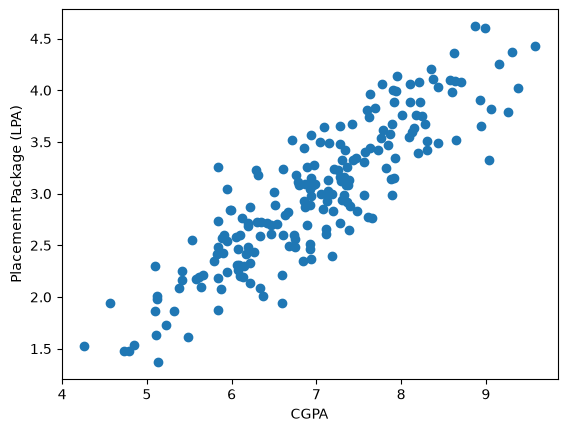

In [4]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Placement Package (LPA)')

In [6]:
X = df['cgpa']
y = df['package']

In [32]:
X_test, X_train, y_test, y_train = train_test_split(X, y, random_state=40, test_size=0.2)

In [ ]:
X_train = X_train.to_frame()
X_test = X_test.to_frame()

In [24]:
lr = LinearRegression()

In [36]:
lr.fit(X_test, y_test)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.59]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['cgpa']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.08
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [ ]:
y_pred = lr.predict(X_test)

array([3.38076852, 2.36660236, 3.19903932, 3.21662602, 2.40763798,
       4.18975655, 2.63626504, 3.07007021, 3.35145736, 3.35731959,
       3.04662129, 2.74764745, 1.76279245, 3.23421271, 2.37246459,
       4.41838361, 3.94940504, 3.82629816, 2.34315343, 2.22590879,
       3.22835048, 2.56591825, 2.6304028 , 3.37490629, 3.47456423,
       2.38418905, 3.55663548, 3.68560459, 3.97285396, 2.9586878 ,
       2.71247405, 3.9787162 , 1.90934825, 2.16142423, 2.98213673,
       2.07349075, 2.34315343, 3.05248352, 3.27524834, 3.10524361,
       3.79112477, 3.50387539, 2.42522468, 1.91521048, 2.86489209,
       2.98799896, 3.12869254, 3.16972816, 3.26938611, 3.58008441,
       2.60695388, 2.98799896, 4.23079218, 3.19317709, 2.9762745 ,
       1.98555727, 2.71247405, 2.47212254, 2.89420325, 1.69244566,
       2.92937664, 3.24007495, 3.25766164, 3.18731486, 3.35145736,
       2.54833155, 2.13211307, 2.03831736, 3.39249298, 3.53318655,
       3.11110584, 2.98799896, 3.67388012, 3.41007968, 2.34315

Model Equation: Price = 0.59 * Size + -1.08
Mean Squared Error (MSE): 0.11
R-squared Score (R²): 0.79


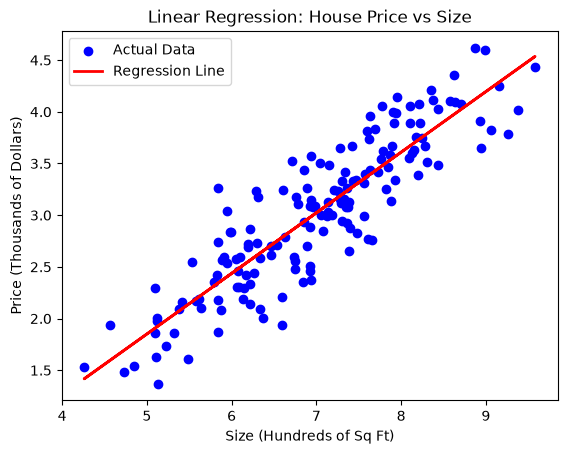

In [54]:
# 5. Extract results and metrics
slope = lr.coef_[0]
intercept = lr.intercept_
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Equation: Price = {slope:.2f} * Size + {intercept:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared Score (R²): {r2:.2f}")

# 6. Visualize the data points and the regression line
plt.scatter(X_test, y_test, color='blue', label='Actual Data')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Regression Line')
plt.title('Linear Regression: House Price vs Size')
plt.xlabel('Size (Hundreds of Sq Ft)')
plt.ylabel('Price (Thousands of Dollars)')
plt.legend()
plt.show()